## Section 1: Setup and Load

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

df = pd.read_parquet('outputs/final_dataset.parquet')
print('Shape:', df.shape)
print()
print('dtypes value counts:')
print(df.dtypes.value_counts())
print()
print('First 3 column names:', list(df.columns[:3]))
print('Last 3 column names:', list(df.columns[-3:]))
print()
print('Target distribution:')
vc = df['readmitted_30d'].value_counts()
pct = df['readmitted_30d'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': vc, 'pct': pct.round(1)}))
rate = df['readmitted_30d'].mean() * 100
print(f'Readmission rate: {rate:.1f}%')
print(f'Row count after Section 1: {df.shape[0]}')

Shape: (23896, 719)

dtypes value counts:
int32     707
object      6
int64       5
Int64       1
Name: count, dtype: int64

First 3 column names: ['subject_id', 'hadm_id', 'gender']
Last 3 column names: ["'SYM017'", "'SYM018'", "'XXX000'"]

Target distribution:
                count   pct
readmitted_30d             
0               19177  80.3
1                4719  19.7
Readmission rate: 19.7%
Row count after Section 1: 23896


## Section 2: Identify Column Groups

In [15]:
non_feature_cols_spec = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime',
    'next_admittime', 'days_to_next', 'readmitted_30d',
    'hospital_expire_flag', 'outcome_class'
]
non_feature_cols = [c for c in non_feature_cols_spec if c in df.columns]

clinical_cols_spec = [
    'gender', 'age_at_admission', 'admission_type', 'insurance',
    'race', 'discharge_location', 'marital_status', 'los_days',
    'came_via_ed', 'prior_admissions_count'
]
clinical_cols = [c for c in clinical_cols_spec if c in df.columns]

ccsr_cols = [c for c in df.columns
             if c not in set(non_feature_cols) and c not in set(clinical_cols)]

print('Total columns:', len(df.columns))
print('Non-feature columns found:', len(non_feature_cols))
print(' ', non_feature_cols)
print('Clinical columns found:', len(clinical_cols))
print(' ', clinical_cols)
print('CCSR columns found:', len(ccsr_cols))
print(f'Row count after Section 2: {df.shape[0]}')

Total columns: 719
Non-feature columns found: 4
  ['subject_id', 'hadm_id', 'days_to_next', 'readmitted_30d']
Clinical columns found: 10
  ['gender', 'age_at_admission', 'admission_type', 'insurance', 'race', 'discharge_location', 'marital_status', 'los_days', 'came_via_ed', 'prior_admissions_count']
CCSR columns found: 705
Row count after Section 2: 23896


## Section 3: Drop Leakage and Invalid Rows

In [16]:
if 'days_to_next' in df.columns:
    df = df.drop(columns=['days_to_next'])
    print('Dropped: days_to_next (future-derived leakage)')
else:
    print('days_to_next not found, nothing to drop')
print('Shape after step 1:', df.shape)

print()
print('discharge_location value counts:')
print(df['discharge_location'].value_counts(dropna=False))

died_mask = df['discharge_location'] == 'DIED'
died_count = int(died_mask.sum())
if died_count > 0:
    df = df[~died_mask].copy()
    print()
    print('Dropped', died_count, 'rows where discharge_location == DIED')
else:
    print()
    print('No DIED rows found, nothing to drop')
print('Shape after step 2:', df.shape)

step3_cols = ['hospital_expire_flag', 'outcome_class', 'admittime', 'dischtime', 'next_admittime']
dropped_step3 = [c for c in step3_cols if c in df.columns]
if dropped_step3:
    df = df.drop(columns=dropped_step3)
    print()
    print('Dropped columns:', dropped_step3)
else:
    print()
    print('None of the step-3 leakage columns were present in df')
print('Shape after step 3:', df.shape)
print(f'Row count after Section 3: {df.shape[0]}')

Dropped: days_to_next (future-derived leakage)
Shape after step 1: (23896, 718)

discharge_location value counts:
discharge_location
HOME                            8761
None                            6577
HOME HEALTH CARE                4476
SKILLED NURSING FACILITY        2321
REHAB                            639
CHRONIC/LONG TERM ACUTE CARE     385
HOSPICE                          238
AGAINST ADVICE                   142
PSYCH FACILITY                   127
ACUTE HOSPITAL                   107
OTHER FACILITY                    74
ASSISTED LIVING                   31
DIED                              15
HEALTHCARE FACILITY                3
Name: count, dtype: int64

Dropped 15 rows where discharge_location == DIED
Shape after step 2: (23881, 718)

None of the step-3 leakage columns were present in df
Shape after step 3: (23881, 718)
Row count after Section 3: 23881


## Section 4: Strip CCSR Column Name Formatting

In [17]:
ccsr_sample_before = [c for c in df.columns
                      if c not in set(non_feature_cols_spec)
                      and c not in set(clinical_cols_spec)]
print('5 sample CCSR column names BEFORE stripping:')
print(ccsr_sample_before[:5])

old_names = list(df.columns)
df.columns = df.columns.str.strip().str.replace("'", '', regex=False)
new_names = list(df.columns)
changed_count = sum(1 for o, n in zip(old_names, new_names) if o != n)

non_feature_cols = [c for c in non_feature_cols_spec if c in df.columns]
clinical_cols = [c for c in clinical_cols_spec if c in df.columns]
ccsr_cols = [c for c in df.columns
             if c not in set(non_feature_cols) and c not in set(clinical_cols)]

print()
print('5 sample CCSR column names AFTER stripping:')
print(ccsr_cols[:5])
print()
print('Columns renamed:', changed_count)
print('CCSR columns redefined:', len(ccsr_cols), 'total')
print(f'Row count after Section 4: {df.shape[0]}')

5 sample CCSR column names BEFORE stripping:
["'1    '", "'10   '", "'100  '", "'101  '", "'102  '"]

5 sample CCSR column names AFTER stripping:
['1    ', '10   ', '100  ', '101  ', '102  ']

Columns renamed: 705
CCSR columns redefined: 705 total
Row count after Section 4: 23881


## Section 5: Handle Missing Values

Missing percentages before imputation:
  discharge_location: 27.54%
  marital_status: 2.12%
  insurance: 1.68%


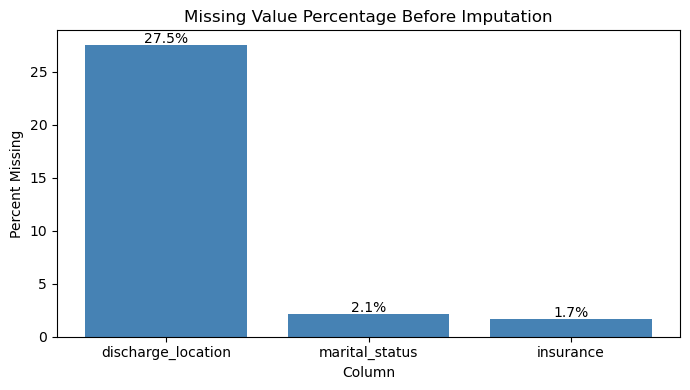


discharge_location: 6577 missing rows flagged in discharge_location_missing
discharge_location: imputed with mode = "HOME"

marital_status: 507 missing rows flagged in marital_status_missing
marital_status: imputed with mode = "MARRIED"

insurance: 402 missing rows flagged in insurance_missing
insurance: imputed with "Other" (neutral category)
age_at_admission: filled 0 missing values with median=60.00
los_days: filled 0 missing values with median=3.00
prior_admissions_count: filled 0 missing values with median=1.00

Missing values AFTER filling:
No missing values remaining
Row count after Section 5: 23881


In [18]:
# Missing value percentages before imputation
cols_to_check = ['discharge_location', 'marital_status', 'insurance']
missing_pct = {c: df[c].isnull().mean() * 100 for c in cols_to_check if c in df.columns}

print('Missing percentages before imputation:')
for col, pct in missing_pct.items():
    print(f'  {col}: {pct:.2f}%')

# Plot missing percentages
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(missing_pct.keys(), missing_pct.values(), color='steelblue')
ax.set_title('Missing Value Percentage Before Imputation')
ax.set_ylabel('Percent Missing')
ax.set_xlabel('Column')
for i, (col, val) in enumerate(missing_pct.items()):
    ax.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Create indicator flags and impute with mode
# Handle discharge_location and marital_status with mode
for col in ['discharge_location', 'marital_status']:
    if col not in df.columns:
        continue
    n_missing = int(df[col].isnull().sum())
    flag_col = f'{col}_missing'
    df[flag_col] = df[col].isnull().astype(int)
    print(f'\n{col}: {n_missing} missing rows flagged in {flag_col}')
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f'{col}: imputed with mode = "{mode_val}"')

# Handle insurance with 'Other' (neutral default)
if 'insurance' in df.columns:
    n_missing = int(df['insurance'].isnull().sum())
    df['insurance_missing'] = df['insurance'].isnull().astype(int)
    print(f'\ninsurance: {n_missing} missing rows flagged in insurance_missing')
    df['insurance'] = df['insurance'].fillna('Other')
    print(f'insurance: imputed with "Other" (neutral category)')

# Numeric columns: fill with median (no change needed, already clean)
for col in ['age_at_admission', 'los_days', 'prior_admissions_count']:
    if col in df.columns:
        n = int(df[col].isnull().sum())
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'{col}: filled {n} missing values with median={med:.2f}')

print()
print('Missing values AFTER filling:')
mv_after = df.isnull().sum()
has_missing_after = mv_after[mv_after > 0]
print(has_missing_after if len(has_missing_after) > 0 else 'No missing values remaining')
print(f'Row count after Section 5: {df.shape[0]}')

## Section 6: Consolidate Race Categories

In [19]:
n_unique_before = df['race'].nunique()
print('Unique race values BEFORE:', n_unique_before)

race_upper = df['race'].fillna('UNKNOWN').str.upper()

conditions = [
    race_upper.str.contains('WHITE',                na=False),
    race_upper.str.contains('BLACK',                na=False),
    race_upper.str.contains('HISPANIC|LATINO',      na=False),
    race_upper.str.contains('ASIAN',                na=False),
    race_upper.str.contains('OTHER|UNABLE|UNKNOWN', na=False),
]
choices = ['WHITE', 'BLACK', 'HISPANIC', 'ASIAN', 'OTHER']
df['race'] = np.select(conditions, choices, default='UNKNOWN')

n_unique_after = df['race'].nunique()
print('Unique race values AFTER:', n_unique_after)
print()
print('Race value counts after consolidation:')
print(df['race'].value_counts())
print(f'Row count after Section 6: {df.shape[0]}')

Unique race values BEFORE: 33
Unique race values AFTER: 6

Race value counts after consolidation:
race
WHITE       15749
BLACK        3890
OTHER        1610
HISPANIC     1494
ASIAN         876
UNKNOWN       262
Name: count, dtype: int64
Row count after Section 6: 23881


## 6b: Outlier Treatment

=== Section 6b: Outlier Treatment ===

los_days: max before = 193.0, 99th percentile = 32.0
prior_admissions_count: max before = 92.0, 99th percentile = 31.0
los_days: max after winsorization = 32.0
prior_admissions_count: max after winsorization = 31.0


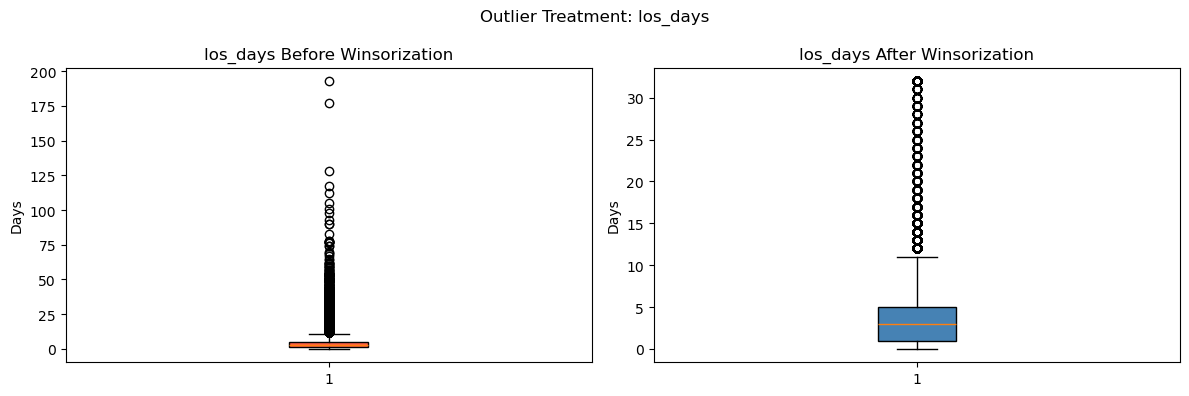

Row count after Section 6b: 23881


In [20]:
print('=== Section 6b: Outlier Treatment ===')
print()

for col in ['los_days', 'prior_admissions_count']:
    if col not in df.columns:
        print(f'{col} not found, skipping')
        continue
    p99 = df[col].quantile(0.99)
    print(f'{col}: max before = {df[col].max():.1f}, 99th percentile = {p99:.1f}')

# Store originals for plotting
los_before = df['los_days'].copy()
prior_before = df['prior_admissions_count'].copy()

# Winsorize at 99th percentile
for col in ['los_days', 'prior_admissions_count']:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=p99)
        print(f'{col}: max after winsorization = {df[col].max():.1f}')

# Plot before and after for los_days
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(los_before.dropna(), patch_artist=True,
                boxprops=dict(facecolor='tomato'))
axes[0].set_title('los_days Before Winsorization')
axes[0].set_ylabel('Days')

axes[1].boxplot(df['los_days'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[1].set_title('los_days After Winsorization')
axes[1].set_ylabel('Days')

plt.suptitle('Outlier Treatment: los_days')
plt.tight_layout()
plt.show()

print(f'Row count after Section 6b: {df.shape[0]}')

## Section 6c: Drop Near-Zero Variance CCSR Features

=== Section 6c: Drop Near-Zero Variance CCSR Features ===

CCSR columns before drop: 705
CCSR columns with less than 1 percent prevalence: 298
CCSR columns after drop: 407
Columns removed: 298


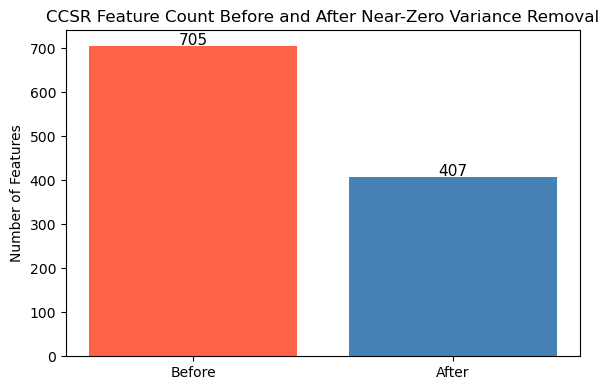

Row count after Section 6c: 23881


In [21]:
print('=== Section 6c: Drop Near-Zero Variance CCSR Features ===')
print()

# Recompute ccsr_cols excluding indicator flag columns
ccsr_cols = [
    c for c in df.columns
    if c not in set(non_feature_cols_spec)
    and c not in set(clinical_cols_spec)
    and not c.endswith('_missing')
    and c != 'readmitted_30d'
]

ccsr_count_before = len(ccsr_cols)
print(f'CCSR columns before drop: {ccsr_count_before}')

# Find columns where fewer than 1% of rows have value == 1
prevalence = df[ccsr_cols].mean()
low_prev_cols = prevalence[prevalence < 0.01].index.tolist()
print(f'CCSR columns with less than 1 percent prevalence: {len(low_prev_cols)}')

df = df.drop(columns=low_prev_cols)

ccsr_cols = [
    c for c in df.columns
    if c not in set(non_feature_cols_spec)
    and c not in set(clinical_cols_spec)
    and not c.endswith('_missing')
    and c != 'readmitted_30d'
]

ccsr_count_after = len(ccsr_cols)
print(f'CCSR columns after drop: {ccsr_count_after}')
print(f'Columns removed: {ccsr_count_before - ccsr_count_after}')

# Plot feature reduction
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Before', 'After'], [ccsr_count_before, ccsr_count_after],
       color=['tomato', 'steelblue'])
ax.set_title('CCSR Feature Count Before and After Near-Zero Variance Removal')
ax.set_ylabel('Number of Features')
for i, val in enumerate([ccsr_count_before, ccsr_count_after]):
    ax.text(i, val + 2, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Row count after Section 6c: {df.shape[0]}')

## Section 7: Encode Categorical Columns

In [22]:
shape_before_enc = df.shape
print('Shape before encoding:', shape_before_enc)

cat_cols_to_encode = [
    'admission_type', 'insurance', 'discharge_location',
    'marital_status', 'race', 'gender'
]
cat_cols_present = [c for c in cat_cols_to_encode if c in df.columns]
print('Columns to encode:', cat_cols_present)

df = pd.get_dummies(df, columns=cat_cols_present, prefix=cat_cols_present, drop_first=False)

new_col_count = df.shape[1] - shape_before_enc[1]
print()
print('Shape after encoding:', df.shape)
print('New columns created:', new_col_count)
print(f'Row count after Section 7: {df.shape[0]}')

Shape before encoding: (23881, 423)
Columns to encode: ['admission_type', 'insurance', 'discharge_location', 'marital_status', 'race', 'gender']

Shape after encoding: (23881, 455)
New columns created: 32
Row count after Section 7: 23881


## Section 8: Scale Numeric Features

=== Section 8: Train/Test Split then Scale ===

Train shape: (19110, 455)
Test shape:  (4771, 455)
Readmission rate in train: 19.7%
Readmission rate in test:  19.8%
Leakage check: 0 patients in both train and test. Clean.

Stats BEFORE scaling (train set only):
  age_at_admission: mean=59.0720, std=18.9249
  los_days: mean=4.4334, std=5.4049
  prior_admissions_count: mean=2.9077, std=5.2725
  came_via_ed: mean=0.6893, std=0.4628

Stats AFTER scaling (train set only):
  age_at_admission: mean=0.0000, std=1.0000
  los_days: mean=-0.0000, std=1.0000
  prior_admissions_count: mean=0.0000, std=1.0000
  came_via_ed: mean=-0.0000, std=1.0000

Scaler fit on train only. Test set transformed separately. No leakage.
Scaler saved to outputs/scaler.pkl


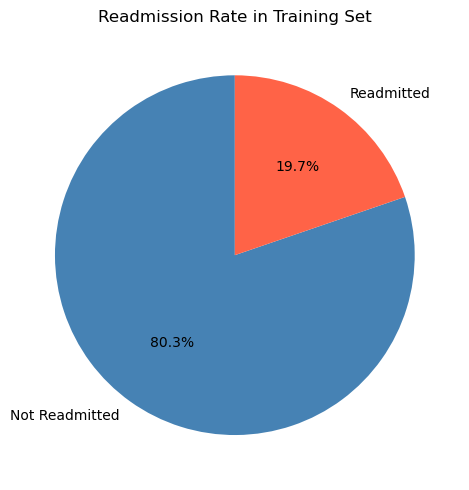

Row count in train: 19110
Row count in test:  4771


In [23]:
print('=== Section 8: Train/Test Split then Scale ===')
print()

# Step 1: Split by subject_id FIRST
patient_ids = df['subject_id'].unique()
train_ids, test_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)
train_df = df[df['subject_id'].isin(train_ids)].copy()
test_df  = df[df['subject_id'].isin(test_ids)].copy()

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_rate = train_df['readmitted_30d'].mean() * 100
test_rate  = test_df['readmitted_30d'].mean() * 100
print(f'Readmission rate in train: {train_rate:.1f}%')
print(f'Readmission rate in test:  {test_rate:.1f}%')

overlap = set(train_ids) & set(test_ids)
assert len(overlap) == 0, f'Leakage: {len(overlap)} patients in both splits'
print(f'Leakage check: {len(overlap)} patients in both train and test. Clean.')

# Step 2: Fit scaler on TRAIN only, transform both
numeric_to_scale = ['age_at_admission', 'los_days', 'prior_admissions_count', 'came_via_ed']
numeric_present = [c for c in numeric_to_scale if c in df.columns]

print()
print('Stats BEFORE scaling (train set only):')
for col in numeric_present:
    print(f'  {col}: mean={train_df[col].mean():.4f}, std={train_df[col].std():.4f}')

scaler = StandardScaler()
train_df[numeric_present] = scaler.fit_transform(train_df[numeric_present].astype(float))
test_df[numeric_present]  = scaler.transform(test_df[numeric_present].astype(float))

print()
print('Stats AFTER scaling (train set only):')
for col in numeric_present:
    print(f'  {col}: mean={train_df[col].mean():.4f}, std={train_df[col].std():.4f}')

joblib.dump(scaler, 'outputs/scaler.pkl')
print()
print('Scaler fit on train only. Test set transformed separately. No leakage.')
print('Scaler saved to outputs/scaler.pkl')

# Step 3: Class balance pie chart for train set
labels = ['Not Readmitted', 'Readmitted']
sizes = train_df['readmitted_30d'].value_counts().sort_index().values
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Readmission Rate in Training Set')
plt.tight_layout()
plt.show()

print(f'Row count in train: {train_df.shape[0]}')
print(f'Row count in test:  {test_df.shape[0]}')

## Section 9: Train Test Split by Patient

In [25]:
print('=== Section 9: Split and Scale Confirmation ===')
print()
print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
print()
train_rate = train_df['readmitted_30d'].mean() * 100
test_rate  = test_df['readmitted_30d'].mean() * 100
print(f'Readmission rate in train: {train_rate:.1f}%')
print(f'Readmission rate in test:  {test_rate:.1f}%')
print()
overlap = set(train_df['subject_id'].unique()) & set(test_df['subject_id'].unique())
print(f'Leakage check: {len(overlap)} patients appear in both sets.')
print()
print('Row count summary:')
print(f'  Total rows in clean dataset: {df.shape[0]}')
print(f'  Train rows: {train_df.shape[0]}')
print(f'  Test rows:  {test_df.shape[0]}')
print(f'  Train + Test: {train_df.shape[0] + test_df.shape[0]}')

=== Section 9: Split and Scale Confirmation ===

Train shape: (19110, 455)
Test shape:  (4771, 455)

Readmission rate in train: 19.7%
Readmission rate in test:  19.8%

Leakage check: 0 patients appear in both sets.

Row count summary:
  Total rows in clean dataset: 23881
  Train rows: 19110
  Test rows:  4771
  Train + Test: 23881


## Section 10: Save Clean Files

In [26]:
id_and_target = ['subject_id', 'hadm_id', 'readmitted_30d']
feature_cols = [c for c in df.columns if c not in id_and_target]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['readmitted_30d']
y_test  = test_df['readmitted_30d']

X_train.to_parquet('outputs/X_train.parquet', index=False)
X_test.to_parquet('outputs/X_test.parquet',   index=False)
y_train.to_csv('outputs/y_train.csv',          index=False)
y_test.to_csv('outputs/y_test.csv',            index=False)
df.to_parquet('outputs/final_dataset_clean.parquet', index=False)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape)
print('y_test: ', y_test.shape)
print('final_dataset_clean:', df.shape)
print()

files_to_check = [
    'outputs/X_train.parquet',
    'outputs/X_test.parquet',
    'outputs/y_train.csv',
    'outputs/y_test.csv',
    'outputs/final_dataset_clean.parquet',
]
for fpath in files_to_check:
    assert os.path.exists(fpath), f'Missing: {fpath}'

print('Preprocessing complete. Ready for modeling.')
print(f'Final row count in full clean dataset: {df.shape[0]}')
print('Expected: 23881 or close depending on near-zero drops')

X_train: (19110, 452)
X_test:  (4771, 452)
y_train: (19110,)
y_test:  (4771,)
final_dataset_clean: (23881, 455)

Preprocessing complete. Ready for modeling.
Final row count in full clean dataset: 23881
Expected: 23881 or close depending on near-zero drops
